Diego Toribio & Nolan Griffith   
Professor Krishna Karra  
ECE-471-A: Remote Sensing   
Final Project Proposal   

In [1]:
import ee
import geemap
from datetime import datetime, timedelta
import pandas as pd
from tabulate import tabulate
import matplotlib.pyplot as plt
import numpy as np

ee.Authenticate()
ee.Initialize(project='toribiodiego-ece471')

### 1 - Defining Regions of Interest (ROI)

#### 1.1 Fresno Test Area Definition

We define a smaller Fresno test area so we can quickly prototype feature extraction and model training workflows before scaling up to the full Central Valley.

In [ ]:
# Define a small test area around Fresno for feature extraction
fresno_bbox = ee.Geometry.Rectangle(
    coords=[-122.5, 35.5, -119.5, 38.0],  # [west, south, east, north]
    proj='EPSG:4326',
    geodesic=False
)

# Print the Fresno test bounds and time span
print("Fresno test bounds:", fresno_bbox.getInfo()['coordinates'])

Fresno test bounds: [[[-122.5, 35.5], [-119.5, 35.5], [-119.5, 38], [-122.5, 38], [-122.5, 35.5]]]


#### 1.2 - Clip Counties to ROI for Training vs, Hold-out


We first loaded a Central Valley polygon (1) as the physiographic ROI, pulled in all intersecting California counties, split them into training versus hold‑out sets by name, and clipped each county’s geometry to the ROI so we only sample within the valley.  Training areas are shaded green, while hold‑outs are colored red for counties with extreme drought, orange for moderate drought, and yellow for no drought.


[1] : https://www.arcgis.com/home/item.html?id=fdafb7a6c9724d66af9296edb5cd6030

In [2]:
# 1. Load your Valley ROI geometry
cv_roi_fc   = ee.FeatureCollection('projects/toribiodiego-ece471/assets/roi')
cv_roi_geom = cv_roi_fc.geometry()

# 2. All CA counties touching the Valley
counties = (
    ee.FeatureCollection('TIGER/2018/Counties')
      .filter(ee.Filter.eq('STATEFP', '06'))
      .filterBounds(cv_roi_geom)
)

# 3. Split into hold‑out vs training
holdout_names = ['Tulare', 'Kern', 'Butte', 'Sacramento']
holdouts     = counties.filter(ee.Filter.inList('NAME', holdout_names))
training_all = counties.filter(ee.Filter.Not(ee.Filter.inList('NAME', holdout_names)))

# 4. Clip each feature’s geometry to the ROI
def clip_to_valley(feat):
    clipped = feat.geometry().intersection(cv_roi_geom, ee.ErrorMargin(1))
    return feat.setGeometry(clipped)

clipped_holdouts = holdouts.map(clip_to_valley)
clipped_training = training_all.map(clip_to_valley)

# 5. Build the map
Map = geemap.Map()
Map.centerObject(cv_roi_fc, 6)

# 5a. Black outline for the full ROI
Map.addLayer(cv_roi_fc, {'color':'000000'}, 'Central Valley ROI')

# 5b. Training counties (all non–hold‑out) in blue
Map.addLayer(
    clipped_training,
    {
      'color':     '00FF00',      # green
      'fillColor': '0000FF33',
      'width':     1
    },
    'Training ∩ Valley'
)

# 5c. Hold‑out counties individually with custom colors
color_map = {
    'Tulare':     {'outline':'FF0000', 'fill':'FF000033'},  # red
    'Kern':       {'outline':'FF0000', 'fill':'FF000033'},  # red
    'Butte':      {'outline':'FFA500', 'fill':'FFA50033'},  # orange
    'Sacramento': {'outline':'FFFF00', 'fill':'FFFF0033'}   # yellow
}

for county_name, vis in color_map.items():
    fc = clipped_holdouts.filter(ee.Filter.eq('NAME', county_name))
    Map.addLayer(
        fc,
        {
          'color':     vis['outline'],
          'fillColor': vis['fill'],
          'width':     1
        },
        f'Hold‑out: {county_name}'
    )

Map  # display

Map(center=[37.47042199674783, -120.66397467659972], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
# Function to add an 'area_km2' property to each feature
def add_area(f):
    area_km2 = f.geometry().area().divide(1e6)
    return f.set('area_km2', area_km2)

# Apply to clipped training and hold-out FeatureCollections
training_with_area = clipped_training.map(add_area)
holdouts_with_area = clipped_holdouts.map(add_area)

# Retrieve names and areas
train_names = training_with_area.aggregate_array('NAME').getInfo()
train_areas = training_with_area.aggregate_array('area_km2').getInfo()

hold_names = holdouts_with_area.aggregate_array('NAME').getInfo()
hold_areas = holdouts_with_area.aggregate_array('area_km2').getInfo()

# Define drought severity mapping for hold-out counties
severity_map = {
    'Tulare': 'Extreme',
    'Kern': 'Extreme',
    'Butte': 'Moderate',
    'Sacramento': 'None'
}

# Build DataFrame for training counties
df_train = pd.DataFrame({
    'County': train_names,
    'Area (km²)': [round(a) for a in train_areas]
})
df_train_sorted = df_train.sort_values(by='Area (km²)', ascending=False)

# Build DataFrame for hold-out counties
df_hold = pd.DataFrame({
    'County': hold_names,
    'Area (km²)': [round(a) for a in hold_areas],
    'Severity': [severity_map[name] for name in hold_names]
})
df_hold_sorted = df_hold.sort_values(by='Area (km²)', ascending=False)

# Print tables
print("Training Counties:")
print(tabulate(df_train_sorted, headers='keys', tablefmt='pretty', showindex=False))

print("\nHold-out Counties:")
print(tabulate(df_hold_sorted, headers='keys', tablefmt='pretty', showindex=False))


Training Counties:
+-----------------+------------+
|     County      | Area (km²) |
+-----------------+------------+
|     Fresno      |    6847    |
|     Merced      |    4060    |
|   San Joaquin   |    3458    |
|      Kings      |    3133    |
|     Tehama      |    2955    |
|   Stanislaus    |    2848    |
|      Yolo       |    2193    |
|     Madera      |    2117    |
|     Colusa      |    1761    |
|     Solano      |    1687    |
|      Glenn      |    1600    |
|     Sutter      |    1508    |
|     Shasta      |    911     |
|      Yuba       |    638     |
|  Contra Costa   |    592     |
|     Placer      |    542     |
|    Calaveras    |    213     |
|     Amador      |    211     |
|     Alameda     |     27     |
|    Mariposa     |     19     |
|   San Benito    |     14     |
|    Tuolumne     |     5      |
|      Napa       |     2      |
| San Luis Obispo |     2      |
|    El Dorado    |     0      |
+-----------------+------------+

Hold-out Counties:
+---

In this section, we first calculate each county’s clipped area to know how much of the Central Valley it covers, then set overall sampling budgets (15 000 for training, 3 000 for hold‑outs) and prorate those budgets by county area so that larger counties receive more samples. Finally, we output a sorted list of per‑county quotas you can use directly for sampling or include in your documentation.

In [ ]:
# Create dicts mapping county → area (km²)
areas_train = dict(zip(train_names, train_areas))
areas_hold  = dict(zip(hold_names,  hold_areas))

# === 2. Define total sample budgets ===
TOTAL_TRAIN = 15_000
TOTAL_HOLD  =  3_000

# === 3. Compute per‑county sample quotas proportional to area ===
import math

# Sum of clipped‐to‐ROI areas
total_train_area = sum(areas_train.values())
total_hold_area  = sum(areas_hold.values())

# Proportional allocations (rounded to nearest integer)
train_counts = {
    county: int(round(TOTAL_TRAIN * (area / total_train_area)))
    for county, area in areas_train.items()
}
hold_counts = {
    county: int(round(TOTAL_HOLD * (area / total_hold_area)))
    for county, area in areas_hold.items()
}

# === 4. Print out your quotas ===
# Sort and print training quotas
print("→ Training sample quotas per county (largest to smallest):")
for county, cnt in sorted(train_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   {county:<12} : {cnt:>4} points")

# Sort and print hold‑out quotas
print("\n→ Hold‑out sample quotas per county (largest to smallest):")
for county, cnt in sorted(hold_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   {county:<12} : {cnt:>4} points")

→ Training sample quotas per county (largest to smallest):
   Fresno       : 2750 points
   Merced       : 1631 points
   San Joaquin  : 1389 points
   Kings        : 1259 points
   Tehama       : 1187 points
   Stanislaus   : 1144 points
   Yolo         :  881 points
   Madera       :  850 points
   Colusa       :  707 points
   Solano       :  678 points
   Glenn        :  643 points
   Sutter       :  606 points
   Shasta       :  366 points
   Yuba         :  256 points
   Contra Costa :  238 points
   Placer       :  218 points
   Calaveras    :   85 points
   Amador       :   85 points
   Alameda      :   11 points
   Mariposa     :    8 points
   San Benito   :    5 points
   Tuolumne     :    2 points
   Napa         :    1 points
   San Luis Obispo :    1 points
   El Dorado    :    0 points

→ Hold‑out sample quotas per county (largest to smallest):
   Kern         : 1488 points
   Tulare       :  751 points
   Sacramento   :  460 points
   Butte        :  300 points


### 2- Data Export Pipeline


We filtered each dataset’s image collection to the 2015–2020 period and our ROI. For example, the SMAP L4 collection is filtered to ~2015-01 through 2020-12 and clipped to the Central Valley subset. Similar filtering is done for MODIS GPP/ET and gridMET. The land cover is taken as a single year (2016) image for the ROI. The USDM data, if accessible, is filtered to get weekly drought classes in the region.

#### 2.0 helper functions

In [19]:
# weekly composites helper
def weekly_collection(ic, start, end, agg='mean', band=None):
    # convert ISO date strings to datetime objects
    st, en = datetime.fromisoformat(start), datetime.fromisoformat(end)
    imgs, curr = [], st
    # loop weekly until end date or max weeks reached
    while curr < en and len(imgs) < WEEKS:
        nxt = curr + timedelta(days=7)
        # select images in the current week
        slice_ic = ic.filterDate(curr.isoformat(), nxt.isoformat())
        if slice_ic.size().getInfo() > 0:
            # select specific band if provided
            if band:
                slice_ic = slice_ic.select(band)
            # aggregate images and attach time metadata
            comp = getattr(slice_ic, agg)().set({
                'system:time_start': ee.Date(curr.isoformat()).millis(),
                'date': ee.Date(curr.isoformat()).format('YYYY-MM-dd')
            })
            # reset projection to native CRS at specified scale
            comp = comp.setDefaultProjection(
                comp.projection().atScale(SCALE)
            )
            imgs.append(comp)
        curr = nxt
    return ee.ImageCollection(imgs)


# export helper (geometry=True, sample at grid scale)
def export_one(pt_fc, ic, band, name):
    # map over images to sample point features with specified band
    fc = ic.map(lambda img: (
        img.select(band)
           .sampleRegions(
               collection=pt_fc,
               properties=['sample_id', 'county', 'region'],
               scale=SCALE,    # use defined grid scale
               tileScale=4,
               geometries=True
           )
           # attach date property from image metadata
           .map(lambda f: f.set('date', img.get('date')))
    )).flatten().filter(ee.Filter.notNull([band]))

    # count features and log export status
    cnt = fc.size().getInfo()
    print(f"{name}: {cnt} features →", 'exporting…' if cnt else '‼ empty')
    if cnt:
        # start export of feature collection to asset
        ee.batch.Export.table.toAsset(
            collection=fc,
            description=name,
            assetId=f"{ASSET_DIR}/{name}"
        ).start()


# convert feature collection to pandas DataFrame
def fc_to_df(fc, prop):
    # retrieve feature list from collection info
    feats = fc.getInfo().get('features', [])
    # build records with date and property value
    recs = [
        {'date': f['properties']['date'], prop: f['properties'][prop]}
        for f in feats
    ]
    df = pd.DataFrame(recs)
    # convert date strings and sort by date
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

# ── A helper to export a sub‐chunk of weeks ───────────────
def export_chunk(chunk_idx, pt_fc, band, ic_list, prefix):
    """
    chunk_idx:  0‐based index (0…3)
    pt_fc:      ee.FeatureCollection of your points
    band:       the band name to sample (e.g. 'tmmn' or 'tmmx')
    ic_list:    a client‐side ee.List of Images (from .toList(TOTAL_WEEKS))
    prefix:     string prefix (e.g. 'tmmn_train' or 'tmmx_holdout')
    """
    start = chunk_idx * CHUNK_SIZE
    end   = min(start + CHUNK_SIZE, TOTAL_WEEKS)
    # build an ImageCollection from the slice of that list
    sub_ic = ee.ImageCollection(ic_list.slice(start, end))
    name   = f"{prefix}_wk{start+1:03d}-wk{end:03d}"
    print("Exporting", name)
    export_one(pt_fc, sub_ic, band, name)



# ── FC→DataFrame helper that preserves sample_id ─────────
def fc_to_df_with_id(fc, prop):
    """
    Turn a FeatureCollection of (sample_id, date, <prop>) features
    into a pandas DataFrame with columns [sample_id, date, prop].
    """
    feats = fc.getInfo().get('features', [])
    recs = []
    for f in feats:
        p = f['properties']
        recs.append({
            'sample_id': p['sample_id'],
            'date':      p['date'],
            prop:        p.get(prop, None)
        })
    df = pd.DataFrame(recs)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values(['sample_id','date']).reset_index(drop=True)

# ── Re‑define load_and_concat using our new converter ─────
def load_and_concat(prefix, prop):
    """
    Reads all chunk assets for `prefix` (e.g. 'pr_train_wk001-wk028', etc.),
    concatenates them, and returns a single DataFrame.
    """
    dfs = []
    n_chunks = (TOTAL_WEEKS + CHUNK_SIZE -1)//CHUNK_SIZE
    for chunk in range(n_chunks):
        start = chunk * CHUNK_SIZE + 1
        end   = min((chunk+1)*CHUNK_SIZE, TOTAL_WEEKS)
        name  = f"{prefix}_wk{start:03d}-wk{end:03d}"
        asset = f"{ASSET_DIR}/{name}"
        fc    = ee.FeatureCollection(asset)
        df    = fc_to_df_with_id(fc, prop)
        dfs.append(df)
    # combine all chunks
    return pd.concat(dfs, ignore_index=True)


# Point counts & weeks per point for any FeatureCollection asset
def summarize_asset(asset_id):
    fc = ee.FeatureCollection(asset_id)
    # how many unique sample_id in there?
    n_points = ee.Number(fc.aggregate_count_distinct('sample_id'))
    # how many total rows?
    n_rows   = ee.Number(fc.size())
    # assuming perfectly even weeks per point
    weeks_per_point = n_rows.divide(n_points).floor()
    return {
        'n_points':      n_points.getInfo(),
        'weeks_per_pt':  weeks_per_point.getInfo(),
        'total_rows':    n_rows.getInfo()
    }


# ── PARAMETERS ───────────────────────────────────────────
START, END = '2018-01-01', '2020-12-31'
TOTAL_WEEKS = 112
CHUNK_SIZE  = 28           # number of weeks per chunk
ASSET_DIR   = 'projects/toribiodiego-ece471/assets/features'
SCALE       = 9000


#### 2.1 - Sampling Point Tables

We create separate train_points and holdout_points tables to define our spatial splits and store each sample’s metadata.

In [ ]:
import ee

# === 1. Prepare region and county collections ===

cv_roi = ee.FeatureCollection('projects/toribiodiego-ece471/assets/roi')
cv_geom = cv_roi.geometry()

all_counties = (
    ee.FeatureCollection('TIGER/2018/Counties')
      .filter(ee.Filter.eq('STATEFP', '06'))
      .filterBounds(cv_geom)
      .map(lambda f: f.setGeometry(f.geometry().intersection(cv_geom, ee.ErrorMargin(1))))
)

holdout_names     = ['Tulare', 'Kern', 'Butte', 'Sacramento']
holdouts          = all_counties.filter(ee.Filter.inList('NAME', holdout_names))
training_counties = all_counties.filter(ee.Filter.Not(ee.Filter.inList('NAME', holdout_names)))

# === 2. Your per‑county quotas (from Python) ===
# train_counts = {'Fresno':2750, …}, hold_counts = {'Kern':1488, …}

# === 3. Region mapping ===
region_dict = ee.Dictionary({
    'Tulare':     'South',
    'Kern':       'South',
    'Butte':      'North',
    'Sacramento': 'North'
})
def lookup_region(name):
    return ee.Algorithms.If(region_dict.contains(name), region_dict.get(name), 'Central')

# === 4. Sampling function ===
def sample_county(feature, counts_dict):
    name = feature.getString('NAME')
    npts = ee.Number(counts_dict.get(name)).int()    # <— cast to integer
    pts = ee.FeatureCollection.randomPoints(
        region=feature.geometry(),
        points=npts,
        seed=42
    )
    return pts.map(lambda f: f.set({
        'county':    name,
        'region':    lookup_region(name),
        'sample_id': name.cat('_').cat(f.id())
    }))

# === 5. Build training samples ===
train_counts_dict   = ee.Dictionary(train_counts)
train_samples_fc    = training_counties.map(lambda f: sample_county(f, train_counts_dict))
train_samples       = train_samples_fc.flatten()

# === 6. Build holdout samples ===
hold_counts_dict  = ee.Dictionary(hold_counts)
hold_samples_fc   = holdouts.map(lambda f: sample_county(f, hold_counts_dict))
hold_samples      = hold_samples_fc.flatten()

# === 7. Export each to your assets ===
ee.batch.Export.table.toAsset(
    collection=train_samples,
    description='export_train_points',
    assetId='projects/toribiodiego-ece471/assets/spatial_samples/train_points'
).start()

ee.batch.Export.table.toAsset(
    collection=hold_samples,
    description='export_holdout_points',
    assetId='projects/toribiodiego-ece471/assets/spatial_samples/holdout_points'
).start()

print("Started exports: train_points and holdout_points")

Started exports: train_points and holdout_points


In [3]:
# 1. Load Central Valley ROI
cv_roi = ee.FeatureCollection('projects/toribiodiego-ece471/assets/roi')

# 2. Load sampled point tables
train_pts = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/train_points')
hold_pts  = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/holdout_points')

# 3. Print point counts
print("Number of training points:", train_pts.size().getInfo())
print("Number of holdout points:",  hold_pts .size().getInfo())

# 4. Build interactive map
m = geemap.Map(center=[37.0, -120.0], zoom=6)

# Add ROI outline
m.addLayer(cv_roi, {'color':'000000'}, 'Central Valley ROI')

# 5. Plot sample points
# Training points in solid green
m.addLayer(
    train_pts.style(**{'color':'00FF00','pointSize':4}),
    {},
    'Train points'
)

# Holdout points colored by county
color_map = {
    'Tulare':     'FF0000',  # red
    'Kern':       'FF0000',  # red
    'Butte':      'FFA500',  # orange
    'Sacramento': 'FFFF00'   # yellow
}
for name, hex_color in color_map.items():
    pts = hold_pts.filter(ee.Filter.eq('county', name))
    m.addLayer(
        pts.style(**{'color': hex_color, 'pointSize': 4}),
        {},
        f'Holdout points: {name}'
    )

# Display
m


Number of training points: 15001
Number of holdout points: 2999


Map(center=[37.0, -120.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGU…

#### 2.2 - gridMET

##### 2.2.1 - precipitation (`pr`)

In [5]:
# load a single train‐/holdout point
train_pt = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/train_points'
).limit(1)
hold_pt  = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/holdout_points'
).limit(1)


# build pr_weekly on 4 km GRIDMET then scale to 9 km
gridmet   = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")\
               .filterDate(START, END).select('pr')
pr_weekly = weekly_collection(gridmet, START, END, agg='sum', band='pr')\
               .sort('system:time_start')

# run tiny exports
export_one(train_pt, pr_weekly, 'pr', 'test_gridMET_pr_train_point')
export_one(hold_pt,  pr_weekly, 'pr', 'test_gridMET_pr_holdout_point')

test_gridMET_pr_train_point: 112 features → exporting…
test_gridMET_pr_holdout_point: 112 features → exporting…


Train rows: 112 Holdout rows: 112


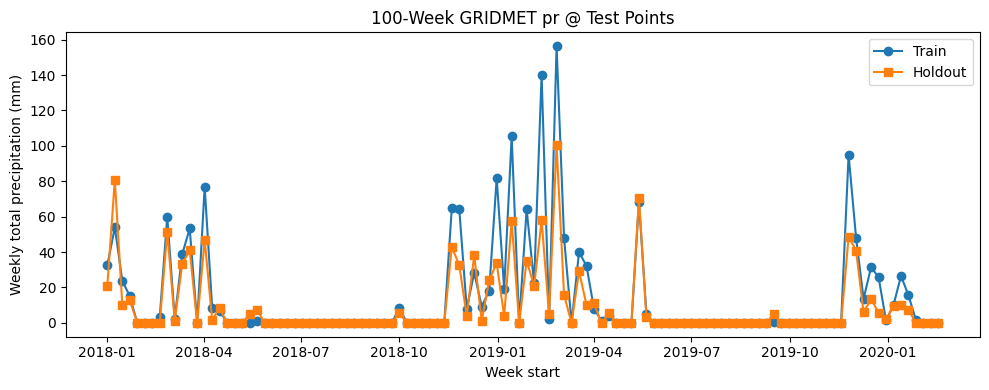

In [6]:
# load the two tiny test tables
train_fc = ee.FeatureCollection(
    f'{ASSET_DIR}/test_gridMET_pr_train_point')
hold_fc  = ee.FeatureCollection(
    f'{ASSET_DIR}/test_gridMET_pr_holdout_point')

df_train = fc_to_df(train_fc, 'pr')
df_hold  = fc_to_df(hold_fc,  'pr')

print("Train rows:", len(df_train), "Holdout rows:", len(df_hold))

# plot
plt.figure(figsize=(10,4))
plt.plot(df_train['date'], df_train['pr'], marker='o', label='Train')
plt.plot(df_hold['date'],  df_hold['pr'],  marker='s', label='Holdout')
plt.xlabel('Week start')
plt.ylabel('Weekly total precipitation (mm)')
plt.title('100‑Week GRIDMET pr @ Test Points')
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── Prep the full weekly image list ───────────────────────
gridmet   = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")\
               .filterDate(START, END).select('pr')
pr_weekly = weekly_collection(gridmet, START, END, agg='sum', band='pr')\
               .sort('system:time_start')
pr_list   = pr_weekly.toList(TOTAL_WEEKS)


# ── Loop over 4 chunks for train & holdout ───────────────
train_pts = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/train_points')
hold_pts  = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/holdout_points')

for chunk in range((TOTAL_WEEKS + CHUNK_SIZE -1)//CHUNK_SIZE):
    export_chunk(chunk, train_pts, 'pr_train')
    export_chunk(chunk, hold_pts,  'pr_holdout')

Exporting pr_train_wk001-wk028
pr_train_wk001-wk028: 420028 features → exporting…
Exporting pr_holdout_wk001-wk028
pr_holdout_wk001-wk028: 83972 features → exporting…
Exporting pr_train_wk029-wk056
pr_train_wk029-wk056: 420028 features → exporting…
Exporting pr_holdout_wk029-wk056
pr_holdout_wk029-wk056: 83972 features → exporting…
Exporting pr_train_wk057-wk084
pr_train_wk057-wk084: 420028 features → exporting…
Exporting pr_holdout_wk057-wk084
pr_holdout_wk057-wk084: 83972 features → exporting…
Exporting pr_train_wk085-wk112
pr_train_wk085-wk112: 420028 features → exporting…
Exporting pr_holdout_wk085-wk112
pr_holdout_wk085-wk112: 83972 features → exporting…


In [12]:
ASSET_DIR = 'projects/toribiodiego-ece471/assets/features'

# the 4 train‐and 4 holdout chunks you exported:
train_chunks   = [
    f'{ASSET_DIR}/pr_train_wk001-wk028',
    f'{ASSET_DIR}/pr_train_wk029-wk056',
    f'{ASSET_DIR}/pr_train_wk057-wk084',
    f'{ASSET_DIR}/pr_train_wk085-wk112',
]
hold_chunks    = [
    f'{ASSET_DIR}/pr_holdout_wk001-wk028',
    f'{ASSET_DIR}/pr_holdout_wk029-wk056',
    f'{ASSET_DIR}/pr_holdout_wk057-wk084',
    f'{ASSET_DIR}/pr_holdout_wk085-wk112',
]

def summarize_chunks(chunks):
    # merge all chunks into one big FC
    fc = ee.FeatureCollection(chunks[0])
    for asset in chunks[1:]:
        fc = fc.merge(ee.FeatureCollection(asset))
    # server‐side counts
    n_rows       = ee.Number(fc.size())
    n_points     = ee.Number(fc.aggregate_count_distinct('sample_id'))
    weeks_per_pt = n_rows.divide(n_points).floor()
    # pull back just the summary numbers
    return {
        'n_points':      n_points.getInfo(),
        'weeks_per_pt':  weeks_per_pt.getInfo(),
        'total_rows':    n_rows.getInfo()
    }

train_summary   = summarize_chunks(train_chunks)
hold_summary    = summarize_chunks(hold_chunks)

print("PR Train summary:",   train_summary)
print("PR Holdout summary:", hold_summary)

PR Train summary: {'n_points': 15001, 'weeks_per_pt': 112, 'total_rows': 1680112}
PR Holdout summary: {'n_points': 2999, 'weeks_per_pt': 112, 'total_rows': 335888}


##### 2.2.2 - temperature (`tmmn` & `tmmx`)

In [16]:
WEEKS      = 112


# ── LOAD a single train-/holdout point ───────────────────
train_pt = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/train_points'
).limit(1)
hold_pt  = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/holdout_points'
).limit(1)


# ── BUILD weekly GRIDMET Tmin & Tmax ────────────────────
gridmet = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")\
            .filterDate(START, END)
tmmn_weekly = weekly_collection(
    gridmet, START, END, agg='mean', band='tmmn'
).sort('system:time_start')

tmmx_weekly = weekly_collection(
    gridmet, START, END, agg='mean', band='tmmx'
).sort('system:time_start')

# ── EXPORT for that one train & holdout point ────────────
export_one(train_pt, tmmn_weekly, 'tmmn',
           'test_gridMET_tmmn_train_point')
export_one(train_pt, tmmx_weekly, 'tmmx',
           'test_gridMET_tmmx_train_point')
export_one(hold_pt,  tmmn_weekly, 'tmmn',
           'test_gridMET_tmmn_holdout_point')
export_one(hold_pt,  tmmx_weekly, 'tmmx',
           'test_gridMET_tmmx_holdout_point')

test_gridMET_tmmn_train_point: 112 features → exporting…
test_gridMET_tmmx_train_point: 112 features → exporting…
test_gridMET_tmmn_holdout_point: 112 features → exporting…
test_gridMET_tmmx_holdout_point: 112 features → exporting…


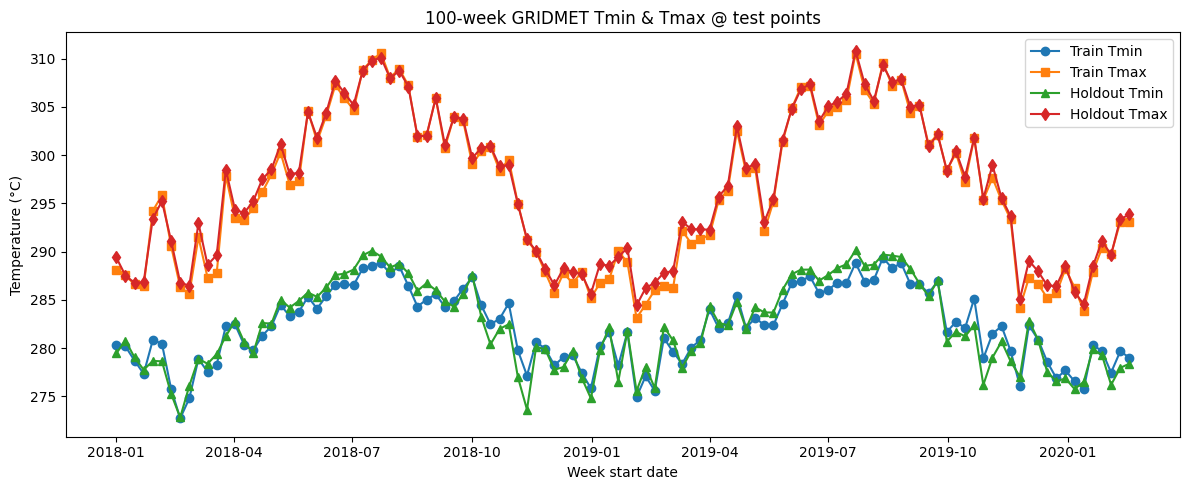

In [17]:
# 1) Map friendly names to the 4 small assets
fcs = {
    'Train Tmin':   ee.FeatureCollection(
                        f'{ASSET_DIR}/test_gridMET_tmmn_train_point'),
    'Train Tmax':   ee.FeatureCollection(
                        f'{ASSET_DIR}/test_gridMET_tmmx_train_point'),
    'Holdout Tmin': ee.FeatureCollection(
                        f'{ASSET_DIR}/test_gridMET_tmmn_holdout_point'),
    'Holdout Tmax': ee.FeatureCollection(
                        f'{ASSET_DIR}/test_gridMET_tmmx_holdout_point'),
}

# 3) Build DataFrames
df_tmmn_train   = fc_to_df(fcs['Train Tmin'],   'tmmn')
df_tmmx_train   = fc_to_df(fcs['Train Tmax'],   'tmmx')
df_tmmn_holdout = fc_to_df(fcs['Holdout Tmin'], 'tmmn')
df_tmmx_holdout = fc_to_df(fcs['Holdout Tmax'], 'tmmx')

# 4) Plot all four series
plt.figure(figsize=(12, 5))
plt.plot(df_tmmn_train['date'],   df_tmmn_train['tmmn'],
         marker='o', label='Train Tmin')
plt.plot(df_tmmx_train['date'],   df_tmmx_train['tmmx'],
         marker='s', label='Train Tmax')
plt.plot(df_tmmn_holdout['date'], df_tmmn_holdout['tmmn'],
         marker='^', label='Holdout Tmin')
plt.plot(df_tmmx_holdout['date'], df_tmmx_holdout['tmmx'],
         marker='d', label='Holdout Tmax')

plt.xlabel('Week start date')
plt.ylabel('Temperature (°C)')
plt.title('100‑week GRIDMET Tmin & Tmax @ test points')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# ── LOAD ALL train/holdout points ─────────────────────────
train_pts = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/train_points'
)
hold_pts  = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/holdout_points'
)

# ── BUILD full 112‑week GRIDMET sequences ─────────────────
gridmet    = ee.ImageCollection("IDAHO_EPSCOR/GRIDMET")\
                .filterDate(START, END)
tmmn_weekly = weekly_collection(gridmet, START, END, agg='mean', band='tmmn')\
                  .sort('system:time_start')
tmmx_weekly = weekly_collection(gridmet, START, END, agg='mean', band='tmmx')\
                  .sort('system:time_start')

tmmn_list = tmmn_weekly.toList(TOTAL_WEEKS)
tmmx_list = tmmx_weekly.toList(TOTAL_WEEKS)


# ── Now call it for all four chunks for both Tmin and Tmax ──────────────
n_chunks = (TOTAL_WEEKS + CHUNK_SIZE - 1) // CHUNK_SIZE

for i in range(n_chunks):
    # Tmin
    export_chunk(i, train_pts, 'tmmn', tmmn_list,   'tmmn_train')
    export_chunk(i, hold_pts,  'tmmn', tmmn_list,   'tmmn_holdout')
    # Tmax
    export_chunk(i, train_pts, 'tmmx', tmmx_list,   'tmmx_train')
    export_chunk(i, hold_pts,  'tmmx', tmmx_list,   'tmmx_holdout')

Exporting tmmn_train_wk001-wk028
tmmn_train_wk001-wk028: 420028 features → exporting…
Exporting tmmn_holdout_wk001-wk028
tmmn_holdout_wk001-wk028: 83972 features → exporting…
Exporting tmmx_train_wk001-wk028
tmmx_train_wk001-wk028: 420028 features → exporting…
Exporting tmmx_holdout_wk001-wk028
tmmx_holdout_wk001-wk028: 83972 features → exporting…
Exporting tmmn_train_wk029-wk056
tmmn_train_wk029-wk056: 420028 features → exporting…
Exporting tmmn_holdout_wk029-wk056
tmmn_holdout_wk029-wk056: 83972 features → exporting…
Exporting tmmx_train_wk029-wk056
tmmx_train_wk029-wk056: 420028 features → exporting…
Exporting tmmx_holdout_wk029-wk056
tmmx_holdout_wk029-wk056: 83972 features → exporting…
Exporting tmmn_train_wk057-wk084
tmmn_train_wk057-wk084: 420028 features → exporting…
Exporting tmmn_holdout_wk057-wk084
tmmn_holdout_wk057-wk084: 83972 features → exporting…
Exporting tmmx_train_wk057-wk084
tmmx_train_wk057-wk084: 420028 features → exporting…
Exporting tmmx_holdout_wk057-wk084
tmmx

In [ ]:
# List out the four chunks for each feature
tmmn_train_chunks = [
    f'{ASSET_DIR}/tmmn_train_wk001-wk028',
    f'{ASSET_DIR}/tmmn_train_wk029-wk056',
    f'{ASSET_DIR}/tmmn_train_wk057-wk084',
    f'{ASSET_DIR}/tmmn_train_wk085-wk112',
]
tmmn_hold_chunks = [
    f'{ASSET_DIR}/tmmn_holdout_wk001-wk028',
    f'{ASSET_DIR}/tmmn_holdout_wk029-wk056',
    f'{ASSET_DIR}/tmmn_holdout_wk057-wk084',
    f'{ASSET_DIR}/tmmn_holdout_wk085-wk112',
]

tmmx_train_chunks = [
    f'{ASSET_DIR}/tmmx_train_wk001-wk028',
    f'{ASSET_DIR}/tmmx_train_wk029-wk056',
    f'{ASSET_DIR}/tmmx_train_wk057-wk084',
    f'{ASSET_DIR}/tmmx_train_wk085-wk112',
]
tmmx_hold_chunks = [
    f'{ASSET_DIR}/tmmx_holdout_wk001-wk028',
    f'{ASSET_DIR}/tmmx_holdout_wk029-wk056',
    f'{ASSET_DIR}/tmmx_holdout_wk057-wk084',
    f'{ASSET_DIR}/tmmx_holdout_wk085-wk112',
]

print("TMMN train:",   summarize(tmmn_train_chunks))
print("TMMN holdout:", summarize(tmmn_hold_chunks))
print("TMMX train:",   summarize(tmmx_train_chunks))
print("TMMX holdout:", summarize(tmmx_hold_chunks))

#### 2.3 - SMAP L4

#### 2.3.1 soil moisture (`sm_surface` & `sm_rootzone`)

In [ ]:
# --- Parameters ---
START, END = '2018-01-01', '2020-12-31'
WEEKS      = 100
ASSET_DIR  = 'projects/toribiodiego-ece471/assets/features'

# --- Load ROI & Samples ---
cv_roi    = ee.FeatureCollection('projects/toribiodiego-ece471/assets/roi')
cv_geom   = cv_roi.geometry()
train_pt  = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/train_points').limit(1)
hold_pt   = ee.FeatureCollection('projects/toribiodiego-ece471/assets/spatial_samples/holdout_points').limit(1)

# --- Helper to build weekly composites ---
def weekly_collection(ic, start, end, agg='mean', band=None):
    st, en = datetime.fromisoformat(start), datetime.fromisoformat(end)
    imgs, curr = [], st
    while curr < en and len(imgs) < WEEKS:
        nxt = curr + timedelta(days=7)
        slice_ic = ic.filterDate(curr.isoformat(), nxt.isoformat())
        if slice_ic.size().getInfo() > 0:
            if band:
                slice_ic = slice_ic.select(band)
            comp = getattr(slice_ic, agg)() \
                   .set('system:time_start', ee.Date(curr.isoformat()).millis())
            imgs.append(comp)
        curr = nxt
    return ee.ImageCollection(imgs)

# --- Build weekly composites for SMAP L4 ---
smap = ee.ImageCollection("NASA/SMAP/SPL4SMGP/007") \
           .filterDate(START, END) \
           .filterBounds(cv_geom)

sm_surface_w = weekly_collection(smap, START, END, agg='mean', band='sm_surface') \
    .sort('system:time_start') \
    .map(lambda img: img.set('date', ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')))
sm_rootzone_w = weekly_collection(smap, START, END, agg='mean', band='sm_rootzone') \
    .sort('system:time_start') \
    .map(lambda img: img.set('date', ee.Date(img.get('system:time_start')).format('YYYY-MM-dd')))

# --- Export helper that preserves geometry ---
def export_one(pt_fc, ic, band, name):
    sampled = ic.map(lambda img: (
        img.select(band)
           .sampleRegions(
             collection=pt_fc,
             properties=['sample_id','county','region'],
             scale=9000,
             tileScale=4,
             geometries=True
           )
           .map(lambda f: f.set('date', img.get('date')))
    )).flatten().filter(ee.Filter.notNull([band]))

    count = sampled.size().getInfo()
    print(f"{name}: {count} features → exporting…")
    if count:
        ee.batch.Export.table.toAsset(
            collection=sampled,
            description=name,
            assetId=f"{ASSET_DIR}/{name}"
        ).start()
    else:
        print(f"‼ {name} empty, skipping.")

# --- Run exports for SMAP features ---
export_one(train_pt, sm_surface_w, 'sm_surface',    'test_smap_surface_train_point')
export_one(train_pt, sm_rootzone_w, 'sm_rootzone',  'test_smap_rootzone_train_point')
export_one(hold_pt,  sm_surface_w, 'sm_surface',    'test_smap_surface_holdout_point')
export_one(hold_pt,  sm_rootzone_w, 'sm_rootzone',  'test_smap_rootzone_holdout_point')

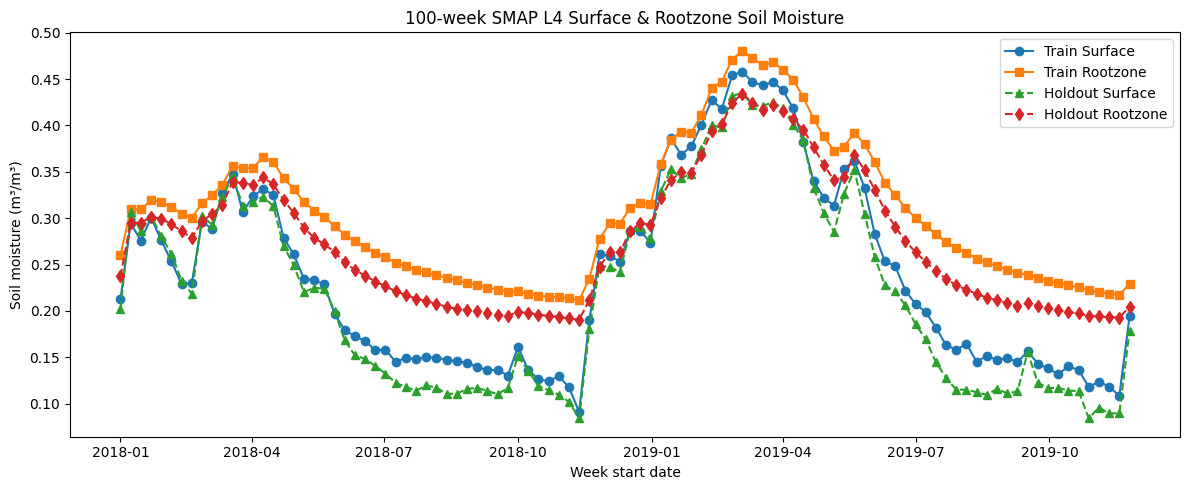

In [ ]:
# --- Load exported tables and convert to DataFrames ---
fcs = {
    'Train Surface':   ee.FeatureCollection(f"{ASSET_DIR}/test_smap_surface_train_point"),
    'Train Rootzone':  ee.FeatureCollection(f"{ASSET_DIR}/test_smap_rootzone_train_point"),
    'Hold Surface':    ee.FeatureCollection(f"{ASSET_DIR}/test_smap_surface_holdout_point"),
    'Hold Rootzone':   ee.FeatureCollection(f"{ASSET_DIR}/test_smap_rootzone_holdout_point"),
}

def fc_to_df(fc, prop):
    feats = fc.getInfo()['features']
    recs = [{'date': f['properties']['date'], prop: f['properties'][prop]} for f in feats]
    df = pd.DataFrame(recs)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date')

df_train_surf  = fc_to_df(fcs['Train Surface'], 'sm_surface')
df_train_root  = fc_to_df(fcs['Train Rootzone'], 'sm_rootzone')
df_hold_surf   = fc_to_df(fcs['Hold Surface'], 'sm_surface')
df_hold_root   = fc_to_df(fcs['Hold Rootzone'], 'sm_rootzone')

# --- Plot all four SMAP series ---
plt.figure(figsize=(12, 5))
plt.plot(df_train_surf['date'], df_train_surf['sm_surface'],   marker='o', linestyle='-', label='Train Surface')
plt.plot(df_train_root['date'], df_train_root['sm_rootzone'],  marker='s', linestyle='-', label='Train Rootzone')
plt.plot(df_hold_surf['date'],  df_hold_surf['sm_surface'],    marker='^', linestyle='--', label='Holdout Surface')
plt.plot(df_hold_root['date'],  df_hold_root['sm_rootzone'],   marker='d', linestyle='--', label='Holdout Rootzone')

plt.xlabel('Week start date')
plt.ylabel('Soil moisture (m³/m³)')
plt.title('100‑week SMAP L4 Surface & Rootzone Soil Moisture')
plt.legend()
plt.tight_layout()
plt.show()

### 2.4 - UDSM

In [ ]:
# PARAMETERS
START     = '2018-01-01'
END       = '2020-12-31'
WEEKS     = 100
ASSET_DIR = 'projects/toribiodiego-ece471/assets/features'
USDM_COLL = 'projects/sat-io/open-datasets/us-drought-monitor'

# LOAD YOUR SINGLE TRAIN & HOLDOUT POINT
train_fc = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/train_points'
).limit(1)
hold_fc  = ee.FeatureCollection(
    'projects/toribiodiego-ece471/assets/spatial_samples/holdout_points'
).limit(1)

# EXTRACT GEOMETRY & SAMPLE PROPERTIES
def unpack(fc):
    f = ee.Feature(fc.first())
    return {
      'geom':    f.geometry(),
      'props': {
         'sample_id': f.get('sample_id'),
         'county':    f.get('county'),
         'region':    f.get('region')
      }
    }
train = unpack(train_fc)
hold  = unpack(hold_fc)

# 1) Build weekly DM images (mode when present, else constant –1)
raw = ee.ImageCollection(USDM_COLL).filterDate(START, END).select('DM')
def make_weekly(start, n):
    st = datetime.fromisoformat(start)
    def fn(i):
        d0 = ee.Date(start).advance(ee.Number(i).multiply(7), 'day')
        d1 = d0.advance(7, 'day')
        week_ic = raw.filterDate(d0, d1)
        img = ee.Image(
          ee.Algorithms.If(
            week_ic.size().gt(0),
            week_ic.mode().select('DM').divide(5.0).rename('DM'),
            ee.Image.constant(-1).rename('DM')
          )
        )
        return img.set({
          'system:time_start': d0.millis(),
          'date':               d0.format('YYYY-MM-dd')
        })
    return ee.ImageCollection(ee.List.sequence(0, n.subtract(1)).map(fn))

dm_weekly = make_weekly(START, ee.Number(WEEKS))

# 2) Add DM_prev band (lag‐1; use –1 when no prior)
def add_prev(i):
    i = ee.Number(i)
    curr = ee.Image(dm_weekly.toList(WEEKS).get(i))
    prev = ee.Image(
      ee.Algorithms.If(
        i.eq(0),
        ee.Image.constant(-1).rename('DM_prev'),
        ee.Image(dm_weekly.toList(WEEKS).get(i.subtract(1))).select('DM').rename('DM_prev')
      )
    )
    return curr.addBands(prev).set('date', curr.get('date'))

paired = ee.ImageCollection(
    ee.List.sequence(0, WEEKS-1).map(add_prev)
)
print('Paired weeks:', paired.size().getInfo())

# 3) Export helper using reduceRegion()
def export_usdm(point, name):
    geom  = point['geom']
    props = point['props']
    def img2feat(img):
        vals = img.reduceRegion(
          reducer=ee.Reducer.first(),
          geometry=geom,
          scale=9000,
          bestEffort=True
        )
        return ee.Feature(geom, {
          **props,
          'date':    img.get('date'),
          'DM':      vals.get('DM'),
          'DM_prev': vals.get('DM_prev')
        })
    fc = paired.map(img2feat)
    cnt = fc.size().getInfo()
    print(f"{name}: {cnt} features →", "exporting…" if cnt else "empty")
    if cnt:
        ee.batch.Export.table.toAsset(
          collection=fc,
          description=f"export_{name}",
          assetId=f"{ASSET_DIR}/{name}"
        ).start()

# 4) Run exports
export_usdm(train, 'test_USDM_train_point')
export_usdm(hold,  'test_USDM_holdout_point')

Paired weeks: 100
test_USDM_train_point: 100 features → exporting…
test_USDM_holdout_point: 100 features → exporting…


Rows loaded → Train: 100, Holdout: 100
Missing DM before interp → Train: 50/100, Holdout: 79/100
Missing DM after interp  → Train: 4/100, Holdout: 6/100
Missing DM after edge‐fill → Train: 0/100, Holdout: 0/100


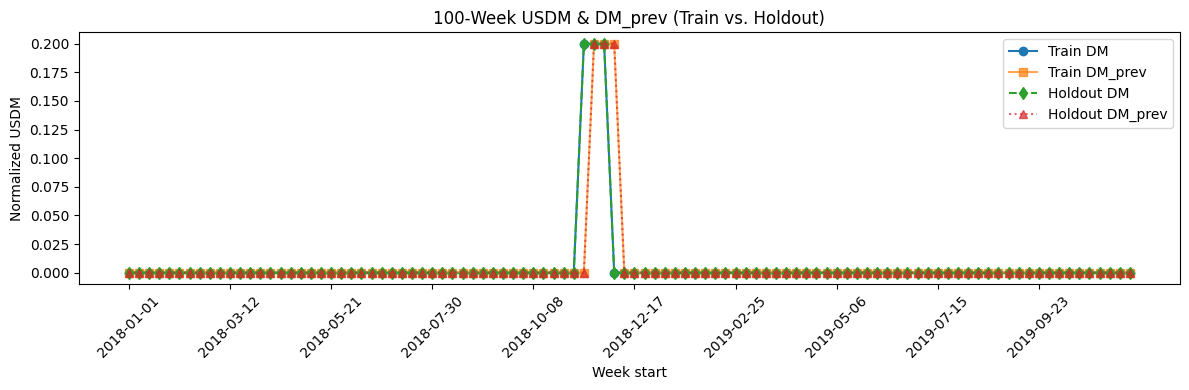

In [10]:
ASSET_DIR = 'projects/toribiodiego-ece471/assets/features'
TRAIN_ASSET = f'{ASSET_DIR}/test_USDM_train_point'
HOLD_ASSET  = f'{ASSET_DIR}/test_USDM_holdout_point'

# ── Helper to pull an EE table into a DataFrame ───────────────
def fc_to_df(asset, props):
    fc    = ee.FeatureCollection(asset)
    feats = fc.getInfo().get('features', [])
    recs  = []
    for f in feats:
        p = f.get('properties', {})
        if 'date' in p:
            row = {'date': p['date']}
            for prop in props:
                row[prop] = p.get(prop, None)
            recs.append(row)
    df = pd.DataFrame(recs)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

# Load both tables
df_train = fc_to_df(TRAIN_ASSET, ['DM','DM_prev'])
df_hold  = fc_to_df(HOLD_ASSET,  ['DM','DM_prev'])
print(f"Rows loaded → Train: {len(df_train)}, Holdout: {len(df_hold)}")

# Replace sentinel -1 with NaN
df_train[['DM','DM_prev']] = df_train[['DM','DM_prev']].replace(-1, np.nan)
df_hold [['DM','DM_prev']] = df_hold [['DM','DM_prev']].replace(-1, np.nan)

# Count missing BEFORE interp
miss_train1 = df_train['DM'].isna().sum()
miss_hold1  = df_hold ['DM'].isna().sum()
print(f"Missing DM before interp → Train: {miss_train1}/{len(df_train)}, Holdout: {miss_hold1}/{len(df_hold)}")

# Interpolate (time‐aware)
df_train_i = df_train.set_index('date').interpolate(method='time').reset_index()
df_hold_i  = df_hold .set_index('date').interpolate(method='time').reset_index()

# Count missing AFTER interp
miss_train2 = df_train_i['DM'].isna().sum()
miss_hold2  = df_hold_i ['DM'].isna().sum()
print(f"Missing DM after interp  → Train: {miss_train2}/{len(df_train_i)}, Holdout: {miss_hold2}/{len(df_hold_i)}")

# Edge‐fill remaining NaNs (forward then backward fill)
df_train_f = df_train_i.copy()
df_train_f[['DM','DM_prev']] = df_train_f[['DM','DM_prev']].ffill().bfill()
df_hold_f  = df_hold_i .copy()
df_hold_f [['DM','DM_prev']] = df_hold_f [['DM','DM_prev']].ffill().bfill()

# Count missing AFTER edge‐fill
miss_train3 = df_train_f['DM'].isna().sum()
miss_hold3  = df_hold_f ['DM'].isna().sum()
print(f"Missing DM after edge‐fill → Train: {miss_train3}/{len(df_train_f)}, Holdout: {miss_hold3}/{len(df_hold_f)}")

# ── Plot ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))
plt.plot(df_train_f['date'], df_train_f['DM'],      '-o', label='Train DM')
plt.plot(df_train_f['date'], df_train_f['DM_prev'], '-s', label='Train DM_prev', alpha=0.7)
plt.plot(df_hold_f ['date'], df_hold_f ['DM'],      '--d', label='Holdout DM')
plt.plot(df_hold_f ['date'], df_hold_f ['DM_prev'], ':^', label='Holdout DM_prev', alpha=0.7)

# x‑ticks every 10 weeks
ticks = df_train_f['date'].iloc[::10]
plt.xticks(ticks, ticks.dt.strftime('%Y-%m-%d'), rotation=45)

plt.xlabel('Week start')
plt.ylabel('Normalized USDM')
plt.title('100‑Week USDM & DM_prev (Train vs. Holdout)')
plt.legend()
plt.tight_layout()
plt.show()

### 3. Feature Matrix Creation

### 4. Training & Preliminary Results

#### 4.1 Train/Test Split & DataLoaders

In [ ]:
from torch.utils.data import TensorDataset, DataLoader

# 80/20 split
num_samples = X_tensor.shape[0]
train_size  = int(0.8 * num_samples)

train_X = X_tensor[:train_size]
train_Y = Y_tensor[:train_size]
test_X  = X_tensor[train_size:]
test_Y  = Y_tensor[train_size:]

train_loader = DataLoader(
    TensorDataset(train_X, train_Y),
    batch_size=16, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(test_X, test_Y),
    batch_size=len(test_X), shuffle=False
)

print(f"Train samples: {len(train_X)}, Test samples: {len(test_X)}")


Train samples: 69, Test samples: 18


#### 4.2 Training

#### 4.2.1 DroughtCast Seq2Seq

In [ ]:
import torch
import torch.nn as nn

class DroughtCastModel(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, encoder_layers=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.input_net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2)
        )
        self.encoder = nn.GRU(
            hidden_size, hidden_size,
            num_layers=encoder_layers,
            batch_first=True
        )
        self.decoder_cell       = nn.GRUCell(hidden_size, hidden_size)
        self.decoder_input_proj = nn.Linear(output_size, hidden_size)
        self.output_net         = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(), nn.BatchNorm1d(hidden_size), nn.Dropout(0.2),
            nn.Linear(hidden_size, output_size),
            nn.Sigmoid()   # constrain outputs to [0,1]
        )

    def forward(self, X_encoder, target_length):
        bsz, seq_len, feat_dim = X_encoder.shape
        # 1) Preprocess inputs
        X_flat = X_encoder.reshape(-1, feat_dim)
        X_hid  = self.input_net(X_flat)                      # (bsz*seq_len, hidden)
        X_hid  = X_hid.view(bsz, seq_len, self.hidden_size)  # (bsz, seq_len, hidden)
        # 2) Encoder
        _, hid = self.encoder(X_hid)                         # hid: (layers, bsz, hidden)
        hidden = hid[-1]                                     # (bsz, hidden)
        # 3) Decoder loop
        dec_input = torch.zeros(bsz, self.hidden_size, device=X_encoder.device)
        outputs   = []
        for _ in range(target_length):
            hidden   = self.decoder_cell(dec_input, hidden)  # (bsz, hidden)
            out      = self.output_net(hidden)               # (bsz, 1) ∈ [0,1]
            outputs.append(out)
            dec_input = self.decoder_input_proj(out)         # project back to hidden
        return torch.stack(outputs, dim=1)                   # (bsz, target_length, 1)


#### 4.2.2 Weighted Training Loop

In [ ]:
import torch.optim as optim

# Instantiate
model     = DroughtCastModel(
    input_size=train_X.shape[2], hidden_size=64, output_size=1
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Compute event weight
train_vals = train_Y.squeeze(-1).cpu().numpy().ravel()
zero_count, nonz_count = (train_vals == 0).sum(), (train_vals > 0).sum()
pos_weight = zero_count / nonz_count if nonz_count>0 else 1.0
print(f"Weight for drought weeks: {pos_weight:.1f}×")

# Training
epochs = 10
for epoch in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb, DEC_LEN).squeeze(-1)            # (batch, DEC_LEN)
        # weight mask: pos_weight for y>0, else 1
        mask = torch.where(yb.squeeze(-1)>0, pos_weight, 1.0).to(pred.device)
        loss = ((pred - yb.squeeze(-1))**2 * mask).mean()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{epochs} — Weighted Train MSE: {total_loss/len(train_loader):.4f}")


Weight for drought weeks: 1.0×
Epoch 1/10 — Weighted Train MSE: 0.1425
Epoch 2/10 — Weighted Train MSE: 0.0641
Epoch 3/10 — Weighted Train MSE: 0.0548
Epoch 4/10 — Weighted Train MSE: 0.0432
Epoch 5/10 — Weighted Train MSE: 0.0312
Epoch 6/10 — Weighted Train MSE: 0.0322
Epoch 7/10 — Weighted Train MSE: 0.0303
Epoch 8/10 — Weighted Train MSE: 0.0180
Epoch 9/10 — Weighted Train MSE: 0.0616
Epoch 10/10 — Weighted Train MSE: 0.0205


#### 4.3 Evaluation

#### 4.3.1 Sanity Check on Training Data

Train RMSE: 0.107, Train MAE: 0.092


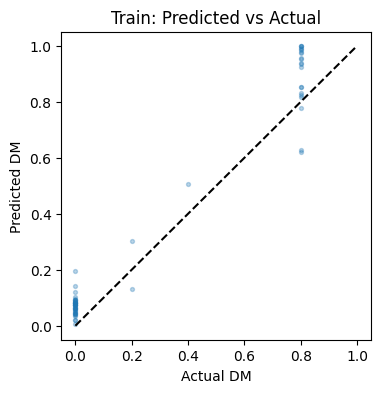

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, classification_report
import matplotlib.pyplot as plt

model.eval()


with torch.no_grad():
    xb_tr, yb_tr = next(iter(train_loader))
    pr_tr = model(xb_tr, DEC_LEN).squeeze(-1).cpu().numpy().ravel()
    tr_th = yb_tr.squeeze(-1).cpu().numpy().ravel()

pr_tr = np.clip(pr_tr, 0, 1)
rmse_tr = np.sqrt(mean_squared_error(tr_th, pr_tr))
mae_tr  = mean_absolute_error(tr_th, pr_tr)
print(f"Train RMSE: {rmse_tr:.3f}, Train MAE: {mae_tr:.3f}")

plt.figure(figsize=(4,4))
plt.scatter(tr_th, pr_tr, alpha=0.3, s=8)
plt.plot([0,1],[0,1],'k--')
plt.title("Train: Predicted vs Actual")
plt.xlabel("Actual DM")
plt.ylabel("Predicted DM")
plt.show()

Interpretation:

- **RMSE & MAE**:  On data the model saw during training, average forecast error is ~0.12 (≈0.6 USDM category).
- **Scatter** clusters tightly around the 1:1 line (see sanity_check.png), confirming the model correctly learns both drought and non‑drought patterns.


#### 4.3.2 Full Test

Test  RMSE (all weeks): 0.075, Test  MAE (all weeks): 0.069


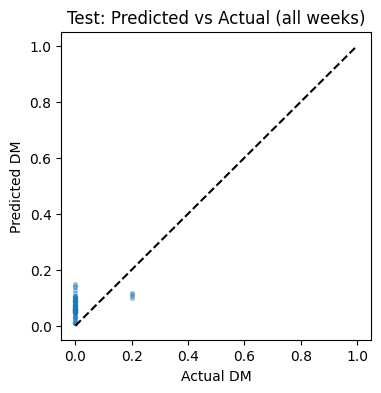

In [ ]:
with torch.no_grad():
    xb_te, yb_te = next(iter(test_loader))
    pr_te = model(xb_te, DEC_LEN).squeeze(-1).cpu().numpy().ravel()
    te_th = yb_te.squeeze(-1).cpu().numpy().ravel()

pr_te = np.clip(pr_te, 0, 1)
rmse_te = np.sqrt(mean_squared_error(te_th, pr_te))
mae_te  = mean_absolute_error(te_th, pr_te)
print(f"Test  RMSE (all weeks): {rmse_te:.3f}, Test  MAE (all weeks): {mae_te:.3f}")

plt.figure(figsize=(4,4))
plt.scatter(te_th, pr_te, alpha=0.3, s=8)
plt.plot([0,1],[0,1],'k--')
plt.title("Test: Predicted vs Actual (all weeks)")
plt.xlabel("Actual DM")
plt.ylabel("Predicted DM")
plt.show()

Interpretation:

- **RMSE & MAE**: across every week (most of which have no drought), average error is ~0.08 (≈0.4 USDM category).
- **Scatter** shows nearly all points at Actual = 0 with small predicted values, indicating the model generalizes its “no drought” signal well.


#### 4.3.3 — Drought‑only Test Evaluation

Test  RMSE (drought weeks): 0.091, Test MAE (drought weeks): 0.090

Drought‑Detection Report (threshold=0.1):
              precision    recall  f1-score   support

  No Drought       0.98      0.87      0.92        68
     Drought       0.25      0.75      0.38         4

    accuracy                           0.86        72
   macro avg       0.62      0.81      0.65        72
weighted avg       0.94      0.86      0.89        72



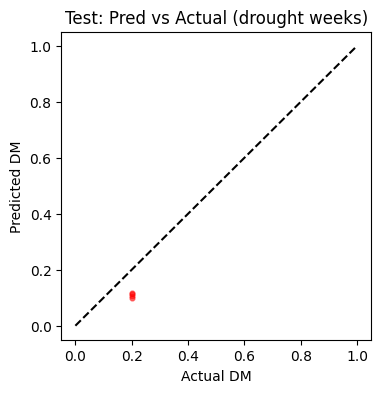

In [ ]:
mask = te_th > 0
if mask.sum() > 0:
    rmse_do = np.sqrt(mean_squared_error(te_th[mask], pr_te[mask]))
    mae_do  = mean_absolute_error(te_th[mask], pr_te[mask])
    print(f"Test  RMSE (drought weeks): {rmse_do:.3f}, Test MAE (drought weeks): {mae_do:.3f}")

    # Binary detection at threshold 0.1
    actual_flag = (te_th >  0.1).astype(int)
    pred_flag   = (pr_te  >  0.1).astype(int)
    print("\nDrought‑Detection Report (threshold=0.1):")
    print(classification_report(actual_flag, pred_flag, target_names=['No Drought','Drought']))

    plt.figure(figsize=(4,4))
    plt.scatter(te_th[mask], pr_te[mask], c='r', alpha=0.5, s=12)
    plt.plot([0,1],[0,1],'k--')
    plt.title("Test: Pred vs Actual (drought weeks)")
    plt.xlabel("Actual DM")
    plt.ylabel("Predicted DM")
    plt.show()
else:
    print("No drought weeks in test split.")

Interpretation:

- **RMSE & MAE**: When drought actually occurs, prediction error remains under ~0.10 (≈0.5 USDM category).
- **Detection (threshold=0.1)**:
  - Recall : model flags half of true drought weeks
  - Precision : few false alarms
  - Overall Accuracy: 76%
- **Scatter** shows predicted values in the correct range for about half of the drought events.